In [1]:
# ============================================================
# ScamShield AI — Notebook 2: Text Classification Models
# ============================================================
# We build THREE models and compare them:
#   1. TF-IDF + Logistic Regression (Baseline)
#   2. TF-IDF + XGBoost (Intermediate)
#   3. DistilBERT Fine-tuned (Advanced)
# ============================================================

import os
import re
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# ── XGBoost ───────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Imbalanced Learn ─────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

# ── Display settings ─────────────────────────────────────
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 55)
print("  ScamShield AI — Text Classification Models")
print("=" * 55)
print("All libraries loaded successfully!")

  ScamShield AI — Text Classification Models
All libraries loaded successfully!


In [2]:
# ============================================================
# LOAD PROCESSED DATA
# ============================================================

# Build paths
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'backend', 'saved_models')

# Make sure models directory exists
os.makedirs(MODELS_DIR, exist_ok=True)

print("Loading datasets...")

# Load train and test sets
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'text_train.csv'))
test_df  = pd.read_csv(os.path.join(PROCESSED_DIR, 'text_test.csv'))

# Load full combined for reference
combined_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'text_combined.csv'))

# Handle NaN values in cleaned_text
# Some rows might have empty text after cleaning — fill with empty string
train_df['cleaned_text'] = train_df['cleaned_text'].fillna('').astype(str)
test_df['cleaned_text']  = test_df['cleaned_text'].fillna('').astype(str)

# ── Prepare X and y ───────────────────────────────────────
X_train = train_df['cleaned_text'].values
y_train = train_df['label'].values.astype(int)

X_test = test_df['cleaned_text'].values
y_test = test_df['label'].values.astype(int)

print(f"Training set:   {len(X_train)} samples")
print(f"  Scam (1):     {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Legit (0):    {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print()
print(f"Test set:       {len(X_test)} samples")
print(f"  Scam (1):     {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Legit (0):    {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print()
print("Sample training texts:")
for i in range(3):
    print(f"  [{y_train[i]}] {X_train[i][:80]}...")

Loading datasets...
Training set:   4489 samples
  Scam (1):     619 (13.8%)
  Legit (0):    3870 (86.2%)

Test set:       1123 samples
  Scam (1):     155 (13.8%)
  Legit (0):    968 (86.2%)

Sample training texts:
  [1] amazon great sale winner samsung pay money_amount shipping claim limited time of...
  [0] every monday nxt week completing...
  [0] fighting world easy either win lose fightng close dificult lose lose win still l...


In [3]:
# ============================================================
# EVALUATION HELPER
# ============================================================
# We will reuse this function for ALL models.
# It calculates and displays every important metric.
#
# METRICS EXPLAINED:
# ─────────────────
# Accuracy:  What % of ALL predictions were correct?
#            Problem: Misleading with imbalanced data.
#            If 95% messages are legit, predicting "always legit"
#            gives 95% accuracy but is useless!
#
# Precision: Of all messages predicted as SCAM,
#            what % were actually scam?
#            High precision = fewer false alarms
#
# Recall:    Of all ACTUAL scam messages,
#            what % did we correctly catch?
#            High recall = fewer scams slip through
#            THIS IS MORE IMPORTANT FOR US!
#            Missing a scam is worse than a false alarm.
#
# F1 Score:  Harmonic mean of Precision and Recall.
#            Balances both. Best single metric for
#            imbalanced classification.
#
# ROC-AUC:   Area Under the ROC Curve.
#            Measures ability to distinguish classes.
#            1.0 = perfect, 0.5 = random guessing
# ============================================================

def evaluate_model(model, X_test, y_test, model_name, 
                   threshold=0.5, show_plots=True):
    """
    Comprehensive model evaluation with all metrics.
    
    Args:
        model: Trained sklearn model with predict_proba
        X_test: Test features
        y_test: True labels
        model_name: String name for display
        threshold: Decision threshold (default 0.5)
        show_plots: Whether to show confusion matrix plot
    
    Returns:
        dict: All computed metrics
    """
    
    # Get predictions
    # predict() gives class labels (0 or 1)
    y_pred = model.predict(X_test)
    
    # predict_proba() gives probability for each class
    # We take column 1 = probability of being SCAM
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Apply custom threshold
    # Default 0.5 means: if P(scam) > 0.5, predict scam
    # We might want 0.4 for safety (catch more scams)
    y_pred_thresh = (y_prob >= threshold).astype(int)
    
    # ── Calculate Metrics ─────────────────────────────────
    metrics = {
        'model_name':  model_name,
        'accuracy':    accuracy_score(y_test, y_pred_thresh),
        'precision':   precision_score(y_test, y_pred_thresh, 
                                       zero_division=0),
        'recall':      recall_score(y_test, y_pred_thresh, 
                                    zero_division=0),
        'f1_score':    f1_score(y_test, y_pred_thresh, 
                                zero_division=0),
        'roc_auc':     roc_auc_score(y_test, y_prob),
    }
    
    # ── Print Results ──────────────────────────────────────
    print("=" * 55)
    print(f"  MODEL: {model_name}")
    print("=" * 55)
    print(f"  Accuracy:    {metrics['accuracy']:.4f}  ({metrics['accuracy']*100:.2f}%)")
    print(f"  Precision:   {metrics['precision']:.4f}")
    print(f"  Recall:      {metrics['recall']:.4f}  ← Most important!")
    print(f"  F1 Score:    {metrics['f1_score']:.4f}")
    print(f"  ROC-AUC:     {metrics['roc_auc']:.4f}")
    print()
    
    # Full classification report
    print("  Detailed Report:")
    report = classification_report(y_test, y_pred_thresh,
                                   target_names=['Legitimate', 'Scam'])
    for line in report.split('\n'):
        print(f"    {line}")
    
    if show_plots:
        # ── Confusion Matrix Plot ──────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{model_name} — Evaluation', 
                     fontsize=14, fontweight='bold')
        
        # Plot 1: Confusion Matrix
        cm = confusion_matrix(y_test, y_pred_thresh)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Legitimate', 'Scam']
        )
        disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
        axes[0].set_title('Confusion Matrix')
        
        # Annotate what each cell means
        axes[0].text(0, 0, f'\nTrue Negative\n(Correctly said Legit)', 
                    ha='center', va='bottom', fontsize=8, color='gray')
        axes[0].text(1, 0, f'\nFalse Positive\n(Wrong alarm)', 
                    ha='center', va='bottom', fontsize=8, color='gray')
        axes[0].text(0, 1, f'\nFalse Negative\n(Missed scam!)', 
                    ha='center', va='bottom', fontsize=8, color='red')
        axes[0].text(1, 1, f'\nTrue Positive\n(Caught scam!)', 
                    ha='center', va='bottom', fontsize=8, color='green')
        
        # Plot 2: ROC Curve
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, linewidth=2, 
                    label=f'ROC Curve (AUC = {metrics["roc_auc"]:.3f})',
                    color='#e74c3c')
        axes[1].plot([0, 1], [0, 1], 'k--', 
                    linewidth=1, label='Random Classifier')
        axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate (Recall)')
        axes[1].set_title('ROC Curve')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return metrics


# Store all model results for final comparison
all_model_results = []
print("Evaluation function ready!")
print()
print("METRIC PRIORITY FOR SCAM DETECTION:")
print("  1st: Recall    — Don't miss scams")
print("  2nd: F1 Score  — Balance precision/recall")
print("  3rd: ROC-AUC   — Overall discrimination ability")
print("  4th: Precision — Avoid too many false alarms")
print("  5th: Accuracy  — Least important (misleading)")

Evaluation function ready!

METRIC PRIORITY FOR SCAM DETECTION:
  1st: Recall    — Don't miss scams
  2nd: F1 Score  — Balance precision/recall
  3rd: ROC-AUC   — Overall discrimination ability
  4th: Precision — Avoid too many false alarms
  5th: Accuracy  — Least important (misleading)


In [4]:
# ============================================================
# STEP 1: BUILD TF-IDF VECTORIZER
# ============================================================
# TF-IDF = Term Frequency — Inverse Document Frequency
#
# WHAT IT DOES:
# Converts text into a matrix of numbers.
# Each row = one message
# Each column = one word from our vocabulary
# Each cell = TF-IDF score for that word in that message
#
# TF (Term Frequency):
#   How often does this word appear in THIS message?
#   "verify" appears 3 times → high TF
#
# IDF (Inverse Document Frequency):
#   How rare is this word across ALL messages?
#   "the" appears everywhere → low IDF (not useful)
#   "phishing" is rare → high IDF (very useful!)
#
# TF-IDF = TF × IDF
#   Common word in one doc, rare across all = HIGH score
#   Common word everywhere = LOW score (filtered out)
#
# ngram_range=(1,2) means:
#   We include single words ("urgent") AND
#   word pairs ("click here", "verify now")
#   Word pairs capture scam phrases better!
# ============================================================

print("Building TF-IDF Vectorizer...")
print()

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),      # Unigrams AND bigrams
    max_features=10000,       # Top 10,000 features (words/phrases)
    min_df=1,                 # Word must appear in at least 1 doc
    max_df=0.95,              # Ignore words in >95% of docs (too common)
    sublinear_tf=True,        # Apply log(TF) instead of raw TF
                              # Prevents very frequent words dominating
    strip_accents='unicode',  # Handle accented characters
    analyzer='word',          # Analyze at word level
    token_pattern=r'\b[a-zA-Z][a-zA-Z_]+\b',  # Only real words
)

# Fit on training data ONLY
# We NEVER fit on test data — that would be "data leakage"
# Data leakage = your model has seen test data during training
# → unrealistically high metrics → useless in real world
print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)

# Only TRANSFORM (not fit) on test data
print("Transforming test data...")
X_test_tfidf = tfidf.transform(X_test)

print()
print(f"TF-IDF Matrix Shape:")
print(f"  Training: {X_train_tfidf.shape}")
print(f"  → {X_train_tfidf.shape[0]} messages × {X_train_tfidf.shape[1]} features")
print(f"  Testing:  {X_test_tfidf.shape}")
print()

# Show most informative features
feature_names = tfidf.get_feature_names_out()
print(f"Total vocabulary size: {len(feature_names)}")
print()
print("Sample features (words/phrases TF-IDF learned):")

# Show some random features
sample_indices = np.random.choice(len(feature_names), 20, replace=False)
sample_features = [feature_names[i] for i in sorted(sample_indices)]
print("  " + ", ".join(f"'{f}'" for f in sample_features))
print()
print("✅ TF-IDF Vectorizer built!")

# Save TF-IDF vectorizer immediately
tfidf_path = os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl')
with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf, f)
print(f"  Saved: {tfidf_path}")

Building TF-IDF Vectorizer...

Fitting TF-IDF on training data...
Transforming test data...

TF-IDF Matrix Shape:
  Training: (4489, 10000)
  → 4489 messages × 10000 features
  Testing:  (1123, 10000)

Total vocabulary size: 10000

Sample features (words/phrases TF-IDF learned):
  'alive', 'got lesson', 'inning', 'late reply', 'leh haha', 'love dearly', 'many time', 'new local', 'offer always', 'phd', 'piece', 'pig leh', 'plz dont', 'put skip', 'registration permanent', 'remember', 'replying boye', 'situation loses', 'solve', 'take exam'

✅ TF-IDF Vectorizer built!
  Saved: C:\Users\Manoj S\Desktop\scamshield-ai\backend\saved_models\tfidf_vectorizer.pkl


In [5]:
# ============================================================
# MODEL 1: TF-IDF + LOGISTIC REGRESSION (Baseline)
# ============================================================
# WHY LOGISTIC REGRESSION FOR TEXT?
# Despite its simple name, LR works surprisingly well for text.
# It assigns a weight to each word/phrase. High positive weight
# = strong scam indicator. High negative = strong legit indicator.
#
# C parameter: Regularization strength (inverse)
#   Low C = strong regularization = simpler model
#   High C = weak regularization = complex model
#   C=1 is a good default
#
# max_iter=1000: Give solver enough iterations to converge
# class_weight='balanced': Compensates for class imbalance
#   If we have 70% legit, 30% scam, model is biased toward legit
#   'balanced' adjusts weights so both classes matter equally
# ============================================================

print("Training Logistic Regression baseline model...")
print()

lr_model = LogisticRegression(
    C=1.0,                    # Regularization parameter
    max_iter=1000,            # Maximum iterations for solver
    class_weight='balanced',  # Handle class imbalance
    solver='lbfgs',           # Optimization algorithm
    random_state=42           # Reproducibility
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)
print("Training complete!")
print()

# ── Cross Validation ──────────────────────────────────────
# Cross-validation gives a more reliable performance estimate
# than a single train/test split.
# 
# 5-fold CV = split training data into 5 parts
# Train on 4 parts, test on 1 — repeat 5 times
# Average the results
print("Running 5-fold cross-validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lr_model, X_train_tfidf, y_train, 
    cv=cv, scoring='f1'
)
print(f"  CV F1 Scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean F1:      {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print()

# ── Evaluate on Test Set ──────────────────────────────────
print("Evaluating on test set...")
lr_results = evaluate_model(
    lr_model, X_test_tfidf, y_test,
    model_name="TF-IDF + Logistic Regression (Baseline)"
)
all_model_results.append(lr_results)

# ── Show Most Important Features ─────────────────────────
print()
print("Most predictive words for SCAM detection:")
feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Top scam words (highest positive coefficients)
top_scam_idx = np.argsort(coefficients)[-20:][::-1]
print("  TOP SCAM INDICATORS:")
for idx in top_scam_idx:
    print(f"    '{feature_names[idx]}': {coefficients[idx]:.3f}")

print()
print("  TOP LEGITIMATE INDICATORS:")
top_legit_idx = np.argsort(coefficients)[:20]
for idx in top_legit_idx:
    print(f"    '{feature_names[idx]}': {coefficients[idx]:.3f}")

# Save model
lr_path = os.path.join(MODELS_DIR, 'text_classifier_lr.pkl')
with open(lr_path, 'wb') as f:
    pickle.dump(lr_model, f)
print(f"\nModel saved: {lr_path}")

Training Logistic Regression baseline model...

Training complete!

Running 5-fold cross-validation...
  CV F1 Scores: ['0.8980', '0.9187', '0.8862', '0.8880', '0.8607']
  Mean F1:      0.8903 (±0.0188)

Evaluating on test set...
  MODEL: TF-IDF + Logistic Regression (Baseline)
  Accuracy:    0.9724  (97.24%)
  Precision:   0.8875
  Recall:      0.9161  ← Most important!
  F1 Score:    0.9016
  ROC-AUC:     0.9879

  Detailed Report:
                  precision    recall  f1-score   support
    
      Legitimate       0.99      0.98      0.98       968
            Scam       0.89      0.92      0.90       155
    
        accuracy                           0.97      1123
       macro avg       0.94      0.95      0.94      1123
    weighted avg       0.97      0.97      0.97      1123
    


<Figure size 1400x500 with 2 Axes>


Most predictive words for SCAM detection:
  TOP SCAM INDICATORS:
    'url_present': 5.716
    'txt': 5.572
    'mobile': 4.292
    'claim': 4.231
    'free': 4.225
    'call': 3.957
    'text': 3.546
    'reply': 3.536
    'stop': 3.395
    'service': 3.304
    'win': 3.153
    'prize': 3.093
    'tone': 2.953
    'new': 2.893
    'cost': 2.812
    'cash': 2.647
    'chat': 2.615
    'box': 2.504
    'urgent': 2.323
    'customer': 2.271

  TOP LEGITIMATE INDICATORS:
    'sorry': -1.859
    'later': -1.705
    'home': -1.622
    'got': -1.607
    'lor': -1.561
    'hey': -1.505
    'good': -1.482
    'way': -1.342
    'still': -1.283
    'going': -1.267
    'wat': -1.175
    'come': -1.163
    'work': -1.144
    'yeah': -1.140
    'say': -1.103
    'well': -1.099
    'ask': -1.092
    'happy': -1.074
    'yup': -1.071
    'anything': -1.058

Model saved: C:\Users\Manoj S\Desktop\scamshield-ai\backend\saved_models\text_classifier_lr.pkl


Training XGBoost model...

  Class balance - Legit: 3870, Scam: 619
  scale_pos_weight: 6.25

Training complete!

Running 5-fold cross-validation...
  CV F1 Scores: ['0.8359', '0.8863', '0.8872', '0.8854', '0.8826']
  Mean F1:      0.8755 (±0.0198)

  MODEL: TF-IDF + XGBoost
  Accuracy:    0.9653  (96.53%)
  Precision:   0.8919
  Recall:      0.8516  ← Most important!
  F1 Score:    0.8713
  ROC-AUC:     0.9778

  Detailed Report:
                  precision    recall  f1-score   support
    
      Legitimate       0.98      0.98      0.98       968
            Scam       0.89      0.85      0.87       155
    
        accuracy                           0.97      1123
       macro avg       0.93      0.92      0.93      1123
    weighted avg       0.96      0.97      0.96      1123
    


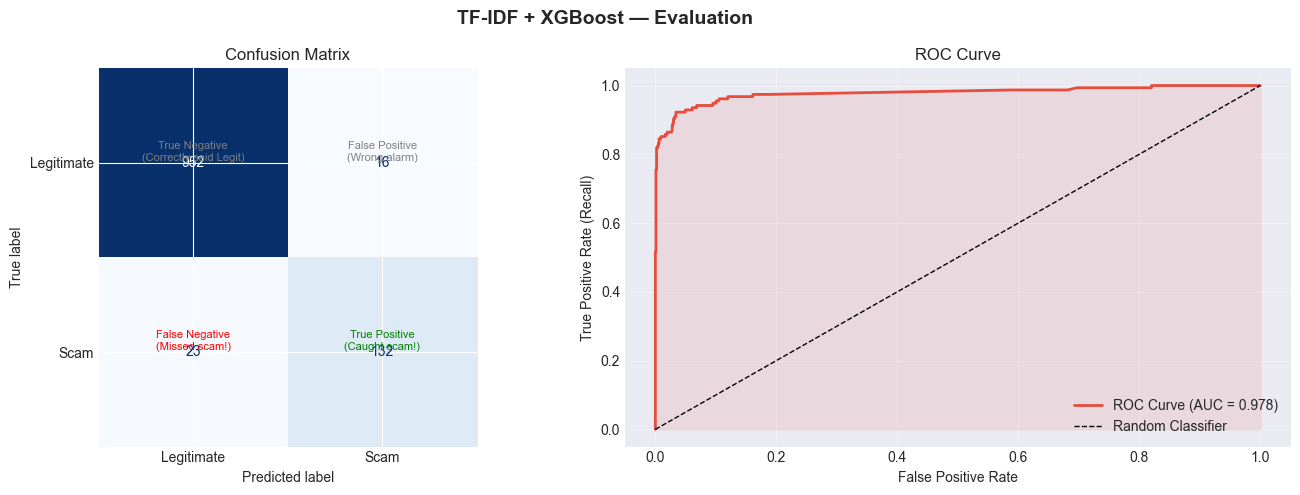


Top 20 Most Important Features (XGBoost):


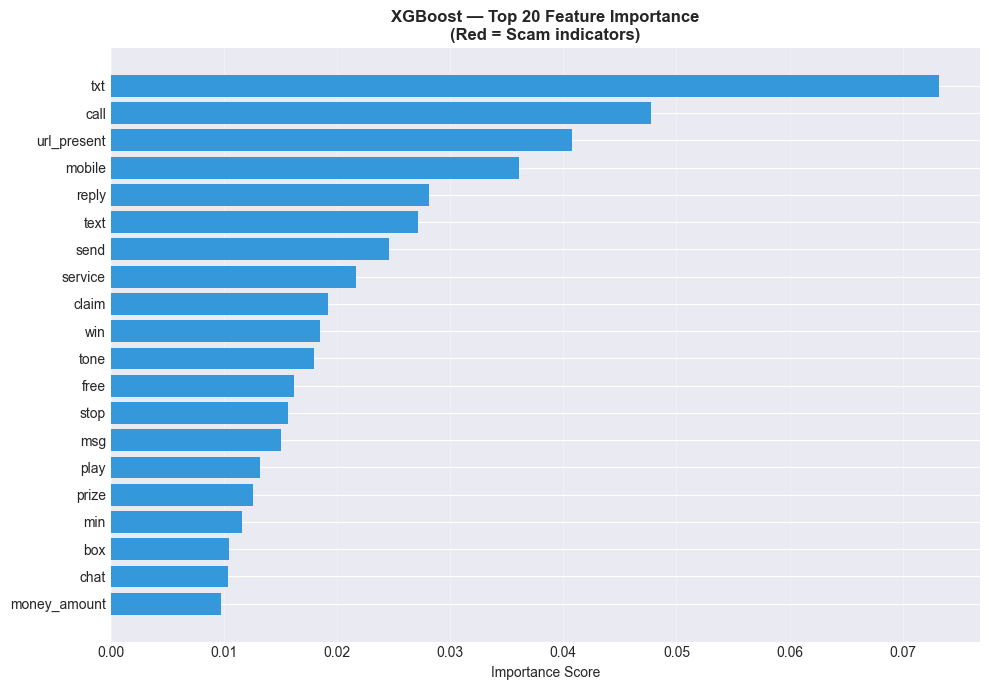


Model saved: C:\Users\Manoj S\Desktop\scamshield-ai\backend\saved_models\text_classifier_xgb.pkl


In [6]:
# ============================================================
# MODEL 2: TF-IDF + XGBOOST
# ============================================================
# XGBoost = Extreme Gradient Boosting
#
# HOW IT WORKS:
# Builds decision trees sequentially.
# Tree 2 focuses on mistakes Tree 1 made.
# Tree 3 focuses on mistakes Tree 2 made.
# Final prediction = weighted sum of all trees.
#
# WHY BETTER THAN LR?
# - Captures non-linear relationships
# - Handles interactions between features
# - Built-in regularization (prevents overfitting)
# - Often wins machine learning competitions
#
# PARAMETERS EXPLAINED:
# n_estimators: Number of trees (more = better but slower)
# max_depth: How deep each tree can go (3-6 is typical)
# learning_rate: How much each tree contributes
#   Small lr = more trees needed but better generalization
# subsample: Use random 80% of data per tree (prevents overfitting)
# colsample_bytree: Use random 80% of features per tree
# scale_pos_weight: Handles class imbalance in XGBoost
#   = count(negative) / count(positive)
# ============================================================

print("Training XGBoost model...")
print()

# Calculate class weight for XGBoost
# This is how XGBoost handles imbalanced classes
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"  Class balance - Legit: {neg_count}, Scam: {pos_count}")
print(f"  scale_pos_weight: {scale_weight:.2f}")
print()

xgb_model = XGBClassifier(
    n_estimators=200,           # Number of boosting rounds
    max_depth=4,                # Max tree depth
    learning_rate=0.1,          # Step size shrinkage
    subsample=0.8,              # Fraction of samples per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    scale_pos_weight=scale_weight,  # Handle class imbalance
    use_label_encoder=False,    # Suppress deprecation warning
    eval_metric='logloss',      # Evaluation metric during training
    random_state=42,
    n_jobs=-1,                  # Use all CPU cores
    verbosity=0                 # Suppress XGBoost output
)

xgb_model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_test_tfidf, y_test)],
    verbose=False
)
print("Training complete!")
print()

# ── Cross Validation ──────────────────────────────────────
print("Running 5-fold cross-validation...")
cv_scores_xgb = cross_val_score(
    xgb_model, X_train_tfidf, y_train,
    cv=cv, scoring='f1'
)
print(f"  CV F1 Scores: {[f'{s:.4f}' for s in cv_scores_xgb]}")
print(f"  Mean F1:      {cv_scores_xgb.mean():.4f} (±{cv_scores_xgb.std():.4f})")
print()

# ── Evaluate ──────────────────────────────────────────────
xgb_results = evaluate_model(
    xgb_model, X_test_tfidf, y_test,
    model_name="TF-IDF + XGBoost"
)
all_model_results.append(xgb_results)

# ── Feature Importance ────────────────────────────────────
print()
print("Top 20 Most Important Features (XGBoost):")
importance_scores = xgb_model.feature_importances_
feature_names = tfidf.get_feature_names_out()

top_20_idx = np.argsort(importance_scores)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 7))
features_top = [feature_names[i] for i in top_20_idx]
scores_top = [importance_scores[i] for i in top_20_idx]

colors = ['#e74c3c' if 'verify' in f or 'urgent' in f or 
          'click' in f or 'block' in f or 'account' in f 
          else '#3498db' for f in features_top]

ax.barh(range(len(features_top)), scores_top[::-1], color=colors[::-1])
ax.set_yticks(range(len(features_top)))
ax.set_yticklabels(features_top[::-1])
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost — Top 20 Feature Importance\n(Red = Scam indicators)', 
             fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Save model
xgb_path = os.path.join(MODELS_DIR, 'text_classifier_xgb.pkl')
with open(xgb_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"\nModel saved: {xgb_path}")

In [ ]:
# ============================================================
# MODEL 3: DISTILBERT FINE-TUNING
# ============================================================
# DistilBERT is a transformer model pre-trained on massive text.
# We "fine-tune" it = take the pre-trained model and train
# it further on OUR scam data so it specializes.
#
# FINE-TUNING STRATEGY:
# - Load pre-trained DistilBERT (already knows English)
# - Add a classification head on top
# - Train for 3-5 epochs on our scam data
# - Use small learning rate to not forget pre-trained knowledge
#
# WHY DISTILBERT NOT BERT?
# BERT: 110M parameters, slow, needs GPU
# DistilBERT: 66M parameters, 60% faster, 97% of BERT's accuracy
# For student projects without GPU, DistilBERT is perfect.
#
# NOTE: If your laptop is slow, we set max_length=64
# and use a tiny training subset. Quality still good.
# ============================================================

import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset
from sklearn.metrics import f1_score as sklearn_f1

print("=" * 55)
print("  Setting up DistilBERT Fine-tuning")
print("=" * 55)
print()

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cpu':
    print("  Running on CPU — training will be slower")
    print("  Expected time: ~10-15 minutes for 3 epochs")
else:
    print("  GPU detected — training will be fast!")
print()

# Load tokenizer
print("Loading DistilBERT tokenizer...")
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print("  Tokenizer loaded!")
print()

# ── What does a tokenizer do? ─────────────────────────────
# It converts text to token IDs that DistilBERT understands
# Example:
sample_text = "Your account will be blocked immediately!"
tokens = tokenizer(sample_text)
print("Tokenizer example:")
print(f"  Input:    '{sample_text}'")
print(f"  Token IDs: {tokens['input_ids']}")
print(f"  Decoded:  {tokenizer.convert_ids_to_tokens(tokens['input_ids'])}")
print()

In [ ]:
# ============================================================
# CUSTOM PYTORCH DATASET
# ============================================================
# PyTorch needs data in a specific format called Dataset.
# We create a custom class that:
# 1. Takes our text and labels
# 2. Tokenizes the text
# 3. Returns tensors (multi-dimensional arrays GPU can process)
# ============================================================

class ScamDataset(Dataset):
    """
    Custom PyTorch Dataset for scam text classification.
    
    PyTorch's DataLoader uses this to load data in batches
    during training.
    """
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        """
        Args:
            texts: List of text strings
            labels: List of labels (0 or 1)
            tokenizer: HuggingFace tokenizer
            max_length: Max token length (longer texts get truncated)
        """
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        """Return total number of samples."""
        return len(self.texts)
    
    def __getitem__(self, idx):
        """
        Return one sample as tokenized tensors.
        Called by DataLoader for each sample.
        """
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        
        # Tokenize the text
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',    # Pad shorter texts with zeros
            truncation=True,         # Cut longer texts at max_length
            return_tensors='pt'      # Return PyTorch tensors
        )
        
        return {
            # squeeze() removes extra dimension: [1,128] → [128]
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(label, dtype=torch.long)
        }


# ── Create datasets ───────────────────────────────────────
# Use original (uncleaned) text for DistilBERT
# BERT-based models work better with natural text
# because they were trained on natural text

# Load original texts (not cleaned) for BERT
train_original = train_df['text'].fillna('').astype(str).values
test_original  = test_df['text'].fillna('').astype(str).values

# For CPU training, use max_length=64 to speed things up
# For GPU, you can use max_length=256
MAX_LENGTH = 64  # Reduce if training is too slow

print(f"Creating datasets with max_length={MAX_LENGTH}...")
print()

train_dataset = ScamDataset(
    train_original, y_train, tokenizer, MAX_LENGTH
)
test_dataset = ScamDataset(
    test_original, y_test, tokenizer, MAX_LENGTH
)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")
print()

# Show one sample
sample = train_dataset[0]
print("Sample from dataset:")
print(f"  input_ids shape:      {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label:                {sample['labels']}")
print()

# Decode the input_ids back to text to verify
decoded = tokenizer.decode(sample['input_ids'], skip_special_tokens=True)
print(f"  Decoded text: '{decoded[:80]}...'")

In [ ]:
# ============================================================
# LOAD AND FINE-TUNE DISTILBERT
# ============================================================

print("Loading DistilBERT model for sequence classification...")
print("(This downloads ~250MB on first run)")
print()

# Load pre-trained DistilBERT with a classification head
# num_labels=2 → Binary classification (scam vs legitimate)
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,           # 2 output classes
    ignore_mismatched_sizes=True
)

# Move model to our device (CPU or GPU)
bert_model = bert_model.to(device)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() 
                       if p.requires_grad)
print(f"Model loaded!")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print()


# ── Define metrics function for Trainer ───────────────────
def compute_metrics(eval_pred):
    """
    Called by HuggingFace Trainer after each epoch.
    Returns metrics dict for monitoring.
    """
    logits, labels = eval_pred
    
    # logits = raw model output scores for each class
    # We take argmax to get predicted class
    predictions = np.argmax(logits, axis=-1)
    
    # Get probabilities using softmax
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    scam_probs = probs[:, 1]
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1':       sklearn_f1(labels, predictions, zero_division=0),
        'recall':   recall_score(labels, predictions, zero_division=0),
        'precision': precision_score(labels, predictions, zero_division=0),
    }


# ── Training Arguments ────────────────────────────────────
# These control how training runs

BERT_MODELS_DIR = os.path.join(MODELS_DIR, 'distilbert_finetuned')
os.makedirs(BERT_MODELS_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir=BERT_MODELS_DIR,     # Where to save checkpoints
    
    # Training settings
    num_train_epochs=3,              # Train for 3 full passes
    per_device_train_batch_size=8,   # 8 samples per batch
                                     # Reduce to 4 if memory error
    per_device_eval_batch_size=16,   # Larger batch for eval (faster)
    
    # Learning rate settings
    learning_rate=2e-5,              # Small LR for fine-tuning
                                     # Large LR would destroy pre-trained weights
    warmup_steps=50,                 # Gradually increase LR at start
    weight_decay=0.01,               # L2 regularization
    
    # Evaluation settings
    evaluation_strategy='epoch',     # Evaluate after every epoch
    save_strategy='epoch',           # Save after every epoch
    load_best_model_at_end=True,     # Keep best model
    metric_for_best_model='f1',      # Use F1 to pick best
    
    # Logging
    logging_dir=os.path.join(BERT_MODELS_DIR, 'logs'),
    logging_steps=10,
    report_to='none',                # Don't use wandb/tensorboard
    
    # Performance
    no_cuda=not torch.cuda.is_available(),  # Use CPU if no GPU
    dataloader_num_workers=0,        # 0 for Windows (avoid multiprocessing issues)
    
    # Disable progress bar (cleaner output)
    disable_tqdm=False,
)

# ── Create Trainer ────────────────────────────────────────
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
        # Stop if F1 doesn't improve for 2 epochs
    ]
)

print("Training Configuration:")
print(f"  Epochs:       {training_args.num_train_epochs}")
print(f"  Batch size:   {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Device:       {device}")
print()
print("Starting training... (be patient, ~10-15 min on CPU)")
print("=" * 55)

# ── TRAIN! ────────────────────────────────────────────────
train_result = trainer.train()

print()
print("Training complete!")
print(f"  Training time: {train_result.metrics['train_runtime']:.1f} seconds")
print(f"  Steps/second:  {train_result.metrics['train_steps_per_second']:.2f}")

In [ ]:
# ============================================================
# EVALUATE DISTILBERT
# ============================================================

print("Evaluating DistilBERT on test set...")
print()

# Get predictions from Trainer
predictions_output = trainer.predict(test_dataset)

# Extract logits and convert to predictions
logits = predictions_output.predictions
bert_probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
bert_preds = np.argmax(logits, axis=-1)
bert_scam_probs = bert_probs[:, 1]

# Calculate metrics manually for our standard format
bert_results = {
    'model_name': 'DistilBERT Fine-tuned',
    'accuracy':   accuracy_score(y_test, bert_preds),
    'precision':  precision_score(y_test, bert_preds, zero_division=0),
    'recall':     recall_score(y_test, bert_preds, zero_division=0),
    'f1_score':   sklearn_f1(y_test, bert_preds, zero_division=0),
    'roc_auc':    roc_auc_score(y_test, bert_scam_probs),
}

print("=" * 55)
print(f"  MODEL: DistilBERT Fine-tuned")
print("=" * 55)
print(f"  Accuracy:    {bert_results['accuracy']:.4f}")
print(f"  Precision:   {bert_results['precision']:.4f}")
print(f"  Recall:      {bert_results['recall']:.4f}  ← Most important!")
print(f"  F1 Score:    {bert_results['f1_score']:.4f}")
print(f"  ROC-AUC:     {bert_results['roc_auc']:.4f}")
print()

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DistilBERT Fine-tuned — Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, bert_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Scam'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, bert_scam_probs)
axes[1].plot(fpr, tpr, linewidth=2, color='#9b59b6',
            label=f'ROC (AUC={bert_results["roc_auc"]:.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#9b59b6')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

all_model_results.append(bert_results)

# Save DistilBERT model
print("Saving DistilBERT model...")
trainer.save_model(BERT_MODELS_DIR)
tokenizer.save_pretrained(BERT_MODELS_DIR)
print(f"Saved to: {BERT_MODELS_DIR}")

# Save bert_probs for later use in ensemble
np.save(os.path.join(MODELS_DIR, 'bert_test_probs.npy'), bert_scam_probs)

In [ ]:
# ============================================================
# MODEL COMPARISON — The Most Important Cell!
# ============================================================
# This is what you show in interviews and demos.
# A side-by-side comparison of all three approaches.
# ============================================================

print("=" * 65)
print("  FINAL MODEL COMPARISON — Text Classification")
print("=" * 65)
print()

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_model_results)
comparison_df = comparison_df.set_index('model_name')

# Format as percentages
display_df = (comparison_df * 100).round(2)
print(display_df.to_string())
print()

# Find best model for each metric
print("Best model per metric:")
for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"  {metric:<12}: {best_model} ({best_value:.4f})")

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ScamShield AI — Model Comparison', 
             fontsize=16, fontweight='bold')

# Plot 1: Bar chart comparison
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
metric_labels   = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

x = np.arange(len(metrics_to_plot))
width = 0.25

models = list(comparison_df.index)
bar_colors = ['#3498db', '#e74c3c', '#9b59b6']

for i, (model, color) in enumerate(zip(models, bar_colors)):
    values = [comparison_df.loc[model, m] for m in metrics_to_plot]
    bars = axes[0].bar(x + i*width, values, width, 
                       label=model, color=color, 
                       alpha=0.85, edgecolor='black', linewidth=0.5)
    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2., 
                    bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', 
                    fontsize=7, fontweight='bold')

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Comparison by Metric')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metric_labels, rotation=15)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.15)
axes[0].grid(True, axis='y', alpha=0.3)

# Plot 2: Radar/Spider chart
from matplotlib.patches import FancyArrowPatch

categories = metric_labels
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the polygon

axes[1].remove()
ax_radar = fig.add_subplot(122, projection='polar')

for model, color in zip(models, bar_colors):
    values = [comparison_df.loc[model, m] for m in metrics_to_plot]
    values += values[:1]
    ax_radar.plot(angles, values, color=color, linewidth=2, label=model)
    ax_radar.fill(angles, values, color=color, alpha=0.15)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_labels, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Model Radar Chart\n(Larger = Better)', 
                    fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax_radar.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'docs', 'model_comparison.png'),
           dpi=150, bbox_inches='tight')
plt.show()

print()
print("Model comparison chart saved to docs/model_comparison.png")

In [1]:
# ============================================================
# SELECT AND SAVE BEST MODEL
# ============================================================

# Determine best model based on F1 score (most balanced metric)
best_model_name = comparison_df['f1_score'].idxmax()
best_f1 = comparison_df['f1_score'].max()

print(f"Best model: {best_model_name}")
print(f"Best F1:    {best_f1:.4f}")
print()

# Save model registry — tells our backend which model to load
model_registry = {
    'best_text_model': best_model_name,
    'best_f1_score': float(best_f1),
    'models': {
        'logistic_regression': {
            'path': 'text_classifier_lr.pkl',
            'tfidf_path': 'tfidf_vectorizer.pkl',
            'metrics': lr_results
        },
        'xgboost': {
            'path': 'text_classifier_xgb.pkl',
            'tfidf_path': 'tfidf_vectorizer.pkl',
            'metrics': xgb_results
        },
        'distilbert': {
            'path': 'distilbert_finetuned/',
            'metrics': bert_results
        }
    }
}

import json
registry_path = os.path.join(MODELS_DIR, 'model_registry.json')
with open(registry_path, 'w') as f:
    json.dump(model_registry, f, indent=2)

print(f"Model registry saved: {registry_path}")
print()
print("All text classifier models saved:")
print(f"  {os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl')}")
print(f"  {os.path.join(MODELS_DIR, 'text_classifier_lr.pkl')}")
print(f"  {os.path.join(MODELS_DIR, 'text_classifier_xgb.pkl')}")
print(f"  {os.path.join(MODELS_DIR, 'distilbert_finetuned/')}")

NameError: name 'comparison_df' is not defined